# NB02 – IPA Horizontal Bar Charts
**Figures for IPA Canonical Pathways (CP) and Diseases & Biofunctions (DB)**

- Y-axis: pathway / disease-function name  
- X-axis: IPA activation z-score  
- Bar colour: pathway category tier  
- Bold text **on** bar: novel gene names  
- Parallel panels: Human (left) | Canine (right)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from pathlib import Path

# ── paths ───────────────────────────────────────────────────────────────────
IPA_FILE  = Path('/content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Supplementary_Files/IPA_All_Species_Annotated.xlsx')
FIG_DIR   = Path('Results/NB02/Figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('matplotlib', matplotlib.__version__)
print('pandas', pd.__version__)
print('IPA file exists:', IPA_FILE.exists())

matplotlib 3.10.0
pandas 2.2.2
IPA file exists: True


In [7]:
# ── colour palette ──────────────────────────────────────────────────────────
CAT_COLORS = {
    # AD-core (reds / oranges)
    'Neutrophil / Degranulation (AD-core)'             : '#C0392B',
    'Innate Immune / Pattern Recognition (AD-core)'    : '#E74C3C',
    'Adaptive Immune (AD-core)'                        : '#E67E22',
    'Cytokine Signalling (AD-core)'                    : '#F39C12',
    'Skin Barrier / Epidermal (AD-core)'               : '#E91E63',
    # Skin-adjacent (greens / teals)
    'Cell Adhesion / ECM (Skin-adjacent)'              : '#27AE60',
    'Lipid / Zinc Metabolism (Skin-adjacent)'          : '#16A085',
    'Ion / Amino Acid Transport (Skin-adjacent)'       : '#1ABC9C',
    'GPCR Signalling (Skin-adjacent)'                  : '#2ECC71',
    'Oxidative Stress (Skin-adjacent)'                 : '#52BE80',
    'Shared Inflammatory Mediators (Skin-adjacent)'    : '#2980B9',
    # Cross-disease / Off-target (purples / blues / greys)
    'Inflammatory Disease (Cross-disease)'             : '#8E44AD',
    'Developmental Signalling (Off-target)'            : '#9B59B6',
    'Metabolic / Endocrine (Off-target)'               : '#7F8C8D',
    'Neurological (Off-target)'                        : '#95A5A6',
    'Other'                                            : '#BDC3C7',
}

# short display labels for the legend
CAT_LABELS = {
    'Neutrophil / Degranulation (AD-core)'             : 'Neutrophil / Degranulation (AD-core)',
    'Innate Immune / Pattern Recognition (AD-core)'    : 'Innate Immune / Pattern Recognition (AD-core)',
    'Adaptive Immune (AD-core)'                        : 'Adaptive Immune (AD-core)',
    'Cytokine Signalling (AD-core)'                    : 'Cytokine Signalling (AD-core)',
    'Skin Barrier / Epidermal (AD-core)'               : 'Skin Barrier / Epidermal (AD-core)',
    'Cell Adhesion / ECM (Skin-adjacent)'              : 'Cell Adhesion / ECM (Skin-adjacent)',
    'Lipid / Zinc Metabolism (Skin-adjacent)'          : 'Lipid / Zinc Metabolism (Skin-adjacent)',
    'Ion / Amino Acid Transport (Skin-adjacent)'       : 'Ion / Amino Acid Transport (Skin-adjacent)',
    'GPCR Signalling (Skin-adjacent)'                  : 'GPCR Signalling (Skin-adjacent)',
    'Oxidative Stress (Skin-adjacent)'                 : 'Oxidative Stress (Skin-adjacent)',
    'Shared Inflammatory Mediators (Skin-adjacent)'    : 'Shared Inflammatory Mediators (Skin-adjacent)',
    'Inflammatory Disease (Cross-disease)'             : 'Inflammatory Disease (Cross-disease)',
    'Developmental Signalling (Off-target)'            : 'Developmental Signalling (Off-target)',
    'Metabolic / Endocrine (Off-target)'               : 'Metabolic / Endocrine (Off-target)',
    'Neurological (Off-target)'                        : 'Neurological (Off-target)',
    'Other'                                            : 'Other',
}

def bar_color(category):
    return CAT_COLORS.get(str(category).strip(), '#BDC3C7')

In [8]:
# ── load data ────────────────────────────────────────────────────────────────
xl = pd.ExcelFile(IPA_FILE)

def load_cp(sheet):
    df = xl.parse(sheet)
    df['z-score']         = pd.to_numeric(df['z-score'],         errors='coerce')
    df['-log(p-value)']   = pd.to_numeric(df['-log(p-value)'],   errors='coerce')
    df['Novel_Genes_in_Row'] = df['Novel_Genes_in_Row'].astype(str).str.strip().replace('nan', '')
    df = df.dropna(subset=['z-score'])
    return df

def load_db(sheet):
    df = xl.parse(sheet)
    df['Activation z-score'] = pd.to_numeric(df['Activation z-score'], errors='coerce')
    df['p-value']            = pd.to_numeric(df['p-value'],            errors='coerce')
    df['Novel_Genes_in_Row'] = df['Novel_Genes_in_Row'].astype(str).str.strip().replace('nan', '')
    df = df.dropna(subset=['Activation z-score'])
    return df

hcp = load_cp('Human_CP')
ccp = load_cp('Canin_CP')
hdb = load_db('Human_DB')
cdb = load_db('Canin_DB')

print(f'Human CP: {len(hcp)} pathways')
print(f'Canine CP: {len(ccp)} pathways')
print(f'Human DB: {len(hdb)} entries')
print(f'Canine DB: {len(cdb)} entries')

Human CP: 47 pathways
Canine CP: 61 pathways
Human DB: 797 entries
Canine DB: 438 entries


In [9]:
# ── helper: shorten long pathway names ──────────────────────────────────────
REPLACEMENTS = [
    ('Signaling Pathway', 'Signaling'),
    ('Signalling Pathway', 'Signalling'),
    ('Role of ', ''),
    ('in Rheumatoid Arthritis Signaling Pathway', ''),
    ('in Rheumatoid Arthritis Signalling Pathway', ''),
    ('Regulation of ', 'Reg. '),
    ('Macrophages, Fibroblasts and Endothelial Cells', 'Macrophages/Fibroblasts/ECs'),
    ('Differential Regulation of Cytokine Production in ', 'Cytokine Diff. '),
    ('Transport of inorganic cations/anions and amino acids/oligopeptides',
     'Inorganic ion / AA transport'),
    ('Transport of bile salts and organic acids, metal ions and amine compounds',
     'Bile salt / metal ion transport'),
    ('Assembly of collagen fibrils and other multimeric structures',
     'Collagen fibril assembly'),
    ('Insulin-like Growth Factor (IGF) transport and uptake by IGFBPs',
     'IGF transport/uptake by IGFBPs'),
    ('Production of Nitric Oxide and Reactive Oxygen Species in Macrophages',
     'NO/ROS in Macrophages'),
    ('Recognition of Bacteria and Viruses', 'Bacterial/Viral Recognition'),
    ('Pathogen Induced Cytokine Storm Signaling Pathway', 'Cytokine Storm'),
    ('Fcγ Receptor-mediated Phagocytosis in Macrophages and Monocytes',
     'FcγR Phagocytosis (Mac/Mono)'),
    ('Crosstalk between Dendritic Cells and Natural Killer Cells',
     'DC–NK Crosstalk'),
    ('Pulmonary Fibrosis Idiopathic Signaling Pathway', 'Pulmonary Fibrosis (IPF)'),
    ('Docosahexaenoic Acid (DHA) Signaling', 'DHA Signaling'),
    ('Role of Hypercytokinemia/hyperchemokinemia in the Pathogenesis of Influenza',
     'Hypercytokinemia/Influenza'),
    ('Irritable Bowel Syndrome Signaling Pathway', 'IBS Signaling'),
    ('Macrophage Classical Activation Signaling Pathway', 'Macrophage Classical Activation'),
    ('Macrophage Alternative Activation Signaling Pathway', 'Macrophage Alternative Activation'),
    ('MyD88:MAL(TIRAP) cascade initiated on plasma membrane', 'MyD88:MAL(TIRAP) cascade'),
    ('Beta-catenin independent WNT signaling', 'WNT (β-cat independent)'),
    ('Neutrophil Extracellular Trap Signaling Pathway', 'NET Signaling'),
    ('CGAS-STING Signaling Pathway', 'cGAS-STING'),
    ('Zn Homeostasis Signaling Pathway', 'Zn Homeostasis'),
    ('Glycerophospholipid biosynthesis', 'Glycerophospholipid Biosynth.'),
    ('RHO GTPases Activate NADPH Oxidases', 'RHO GTPases / NADPH Oxidases'),
    ('Degradation of the extracellular matrix', 'ECM Degradation'),
    ('Collagen biosynthesis and modifying enzymes', 'Collagen Biosynthesis'),
    ('Collagen chain trimerization', 'Collagen Trimerization'),
    ('Interleukin-10 signaling', 'IL-10 Signaling'),
    ('Interleukin-4 and Interleukin-13 signaling', 'IL-4/IL-13 Signaling'),
    ('Interleukin-3, Interleukin-5 and GM-CSF signaling', 'IL-3/IL-5/GM-CSF Signaling'),
    ('Interleukin-2 family signaling', 'IL-2 Family Signaling'),
    ('G-Protein Coupled Receptor Signaling', 'GPCR Signaling'),
    ('G alpha (i) signalling events', 'Gα(i) Signaling'),
    ('G alpha (q) signalling events', 'Gα(q) Signaling'),
    ('Class A/1 (Rhodopsin-like receptors)', 'Rhodopsin-like Receptors'),
    ('Post-translational protein phosphorylation', 'Post-transl. Phosphorylation'),
    ('Tumor Microenvironment Pathway', 'Tumor Microenvironment'),
    ('Sheddase Signaling Pathway', 'Sheddase Signaling'),
    ('Wound Healing Signaling Pathway', 'Wound Healing'),
    ('IL-17A Signaling in Fibroblasts', 'IL-17A / Fibroblasts'),
    ('Role of JAK family kinases in IL-6-type Cytokine Signaling',
     'JAK Kinases / IL-6 Cytokines'),
    ('MHC class II antigen presentation', 'MHC-II Antigen Presentation'),
    ('Interferon gamma signaling', 'IFN-γ Signaling'),
    ('PIP3 activates AKT signaling', 'PIP3/AKT Signaling'),
    ('Adrenergic Receptor Signaling Pathway (Enhanced)', 'Adrenergic Receptor Signaling'),
    ('NLR signaling pathways', 'NLR Signaling'),
    ('Leukocyte Extravasation Signaling', 'Leukocyte Extravasation'),
    ('MSP-RON Signaling in Macrophages Pathway', 'MSP-RON Signaling (Mac)'),
    ('Co-inhibition by PD-1', 'PD-1 Co-inhibition'),
    ('Hepatic Fibrosis Signaling Pathway', 'Hepatic Fibrosis Signaling'),
    ('Extracellular matrix organization', 'ECM Organization'),
    ('Integrin cell surface interactions', 'Integrin–Cell Surface Interactions'),
    ('Collagen degradation', 'Collagen Degradation'),
    ('Eicosanoid Signaling', 'Eicosanoid Signaling'),
    ('Peroxisomal lipid metabolism', 'Peroxisomal Lipid Metabolism'),
    ('Atherosclerosis Signaling', 'Atherosclerosis Signaling'),
    ('Glycation Signaling Pathway', 'Glycation Signaling'),
    ('Glycation Signaling', 'Glycation Signaling'),
    ('Hepatic Cholestasis', 'Hepatic Cholestasis'),
    ('Neuroinflammation Signaling Pathway', 'Neuroinflammation Signaling'),
    ('Cell surface interactions at the vascular wall', 'Vascular Wall Interactions'),
]

def shorten(name, maxlen=52):
    s = str(name)
    for old, new in REPLACEMENTS:
        s = s.replace(old, new)
    s = s.strip(', ')
    if len(s) > maxlen:
        s = s[:maxlen-1] + '…'
    return s

In [10]:
# ── core bar-chart drawing function ─────────────────────────────────────────
def draw_bar_panel(ax, df, name_col, zscore_col, novel_col,
                   cat_col, species_label, max_z=None,
                   bar_height=0.65, gene_fontsize=7.5,
                   min_bar_for_inside=0.8):
    """
    Draw a horizontal bar chart onto `ax`.

    Novel gene names are printed in **bold** directly on the bar when the bar
    is long enough; otherwise they are placed just to the right of the bar tip.
    """
    df = df.copy().reset_index(drop=True)
    n  = len(df)
    ys = np.arange(n)

    if max_z is None:
        max_z = df[zscore_col].abs().max() * 1.15

    colors = [bar_color(c) for c in df[cat_col]]

    bars = ax.barh(ys, df[zscore_col], height=bar_height,
                   color=colors, edgecolor='white', linewidth=0.4,
                   zorder=3)

    # vertical grid lines (subtle)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color='#E0E0E0', linewidth=0.6, zorder=0)

    # novel gene labels
    for i, (z, genes) in enumerate(zip(df[zscore_col], df[novel_col])):
        if not genes or str(genes).strip() in ('', 'nan'):
            continue
        label = genes.strip()
        bar_len = abs(z)
        # decide: inside or outside?
        if bar_len >= min_bar_for_inside:
            # place inside bar at 60% of the bar width from the origin
            x_pos   = z * 0.55
            h_align = 'center'
            color   = 'white'
        else:
            # place just outside to the right of the bar tip
            x_pos   = z + 0.08
            h_align = 'left'
            color   = '#333333'
        ax.text(x_pos, i, label,
                ha=h_align, va='center',
                fontsize=gene_fontsize, fontweight='bold',
                color=color, clip_on=False, zorder=5)

    # y-axis: pathway names
    short_names = [shorten(nm) for nm in df[name_col]]
    ax.set_yticks(ys)
    ax.set_yticklabels(short_names, fontsize=7.5)
    ax.invert_yaxis()          # top = highest z-score

    ax.set_xlim(0, max_z)
    ax.set_xlabel('IPA activation z-score', fontsize=9)
    ax.set_title(species_label, fontsize=11, fontweight='bold', pad=6)

    # spine cleanup
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    # z-score reference lines
    for xv, ls in [(2.0, '--'), (3.0, ':')]:
        ax.axvline(xv, color='#AAAAAA', linewidth=0.8, linestyle=ls, zorder=1)

    return max_z

In [11]:
# ── legend builder ──────────────────────────────────────────────────────────
def make_legend(fig, categories_present, ncol=2,
                y_anchor=0.01, fontsize=8):
    patches = []
    seen    = set()
    for cat in categories_present:
        cat = str(cat).strip()
        if cat not in seen and cat in CAT_COLORS:
            seen.add(cat)
            patches.append(
                mpatches.Patch(facecolor=CAT_COLORS[cat],
                               edgecolor='white', linewidth=0.4,
                               label=cat)
            )
    fig.legend(handles=patches,
               loc='lower center',
               bbox_to_anchor=(0.5, y_anchor),
               ncol=ncol,
               fontsize=fontsize,
               frameon=True,
               framealpha=0.9,
               edgecolor='#CCCCCC',
               title='Pathway category',
               title_fontsize=fontsize)

---
## Figure CP: Canonical Pathways

In [12]:
# ── prepare CP data ──────────────────────────────────────────────────────────
# Human CP: all pathways, sorted by z-score desc
hcp_plot = (
    hcp
    .sort_values('z-score', ascending=False)
    .reset_index(drop=True)
)

# Canine CP: exclude uncategorised 'Other'; sort by z-score desc
ccp_plot = (
    ccp[ccp['Pathway_Category'] != 'Other']
    .sort_values('z-score', ascending=False)
    .reset_index(drop=True)
)

print(f'Human CP rows for plot : {len(hcp_plot)}')
print(f'Canine CP rows for plot: {len(ccp_plot)}')

# shared max z-score for matching x-axis scales
max_z_cp = max(hcp_plot['z-score'].max(),
               ccp_plot['z-score'].max()) * 1.20

Human CP rows for plot : 47
Canine CP rows for plot: 35


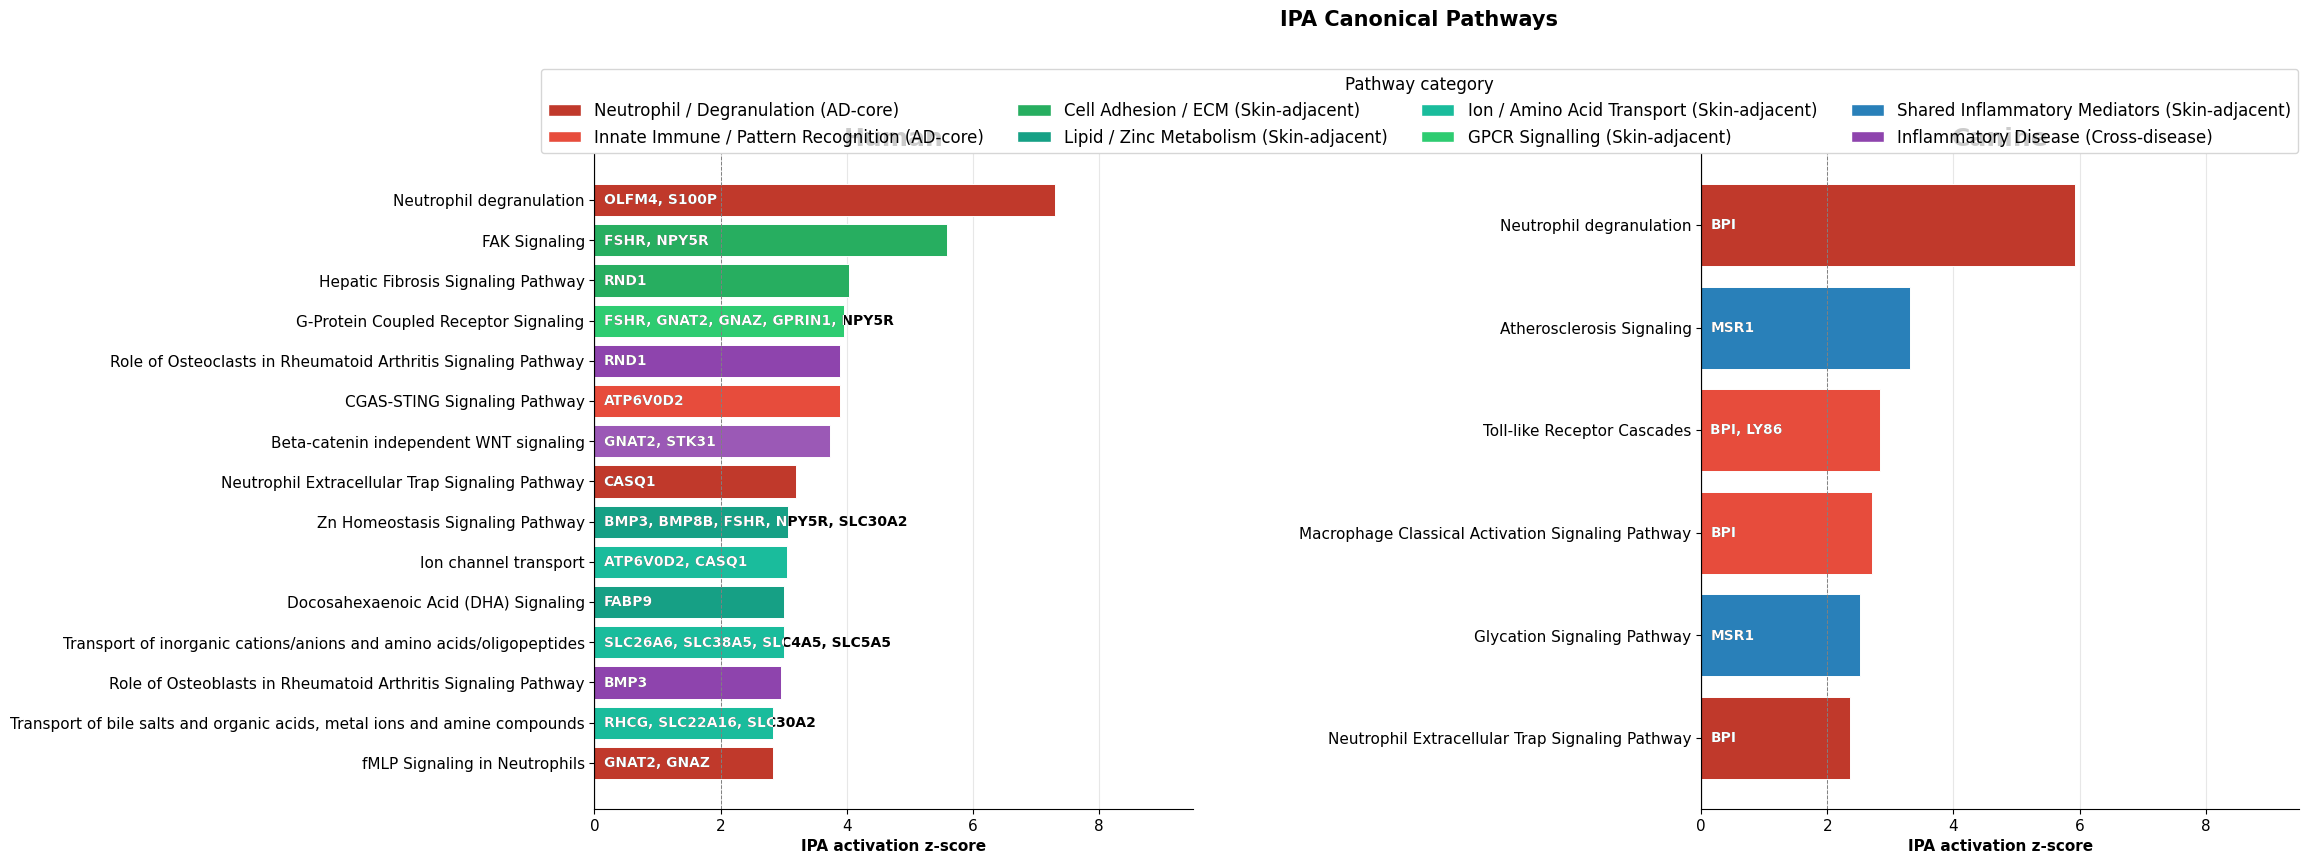

Saved → /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-CP_ZScore_BarChart.pdf
Saved → /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-CP_ZScore_BarChart.png
Saved → /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-CP_ZScore_BarChart.jpeg


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ── Helper: draw one panel ───────────────────────────────────────────────────
def draw_bar_panel(ax, df, name_col, zscore_col, novel_col, cat_col,
                   species_label, max_z):

    df = df.copy()
    df[zscore_col] = pd.to_numeric(df[zscore_col], errors="coerce")
    df = df.dropna(subset=[zscore_col])
    df = df.sort_values(zscore_col, ascending=True)

    y_pos = np.arange(len(df))

    colors = [
        CAT_COLORS.get(cat, "#808080")
        for cat in df[cat_col]
    ]

    bars = ax.barh(
        y_pos,
        df[zscore_col],
        color=colors,
        edgecolor="white",
        linewidth=0.7
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df[name_col], fontsize=11)

    ax.set_xlim(0, max_z * 1.30)

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    ax.set_xlabel("IPA activation z-score", fontsize=11, fontweight="bold")
    ax.set_title(species_label, fontsize=18, fontweight="bold")

    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(2, color="gray", linestyle="--", linewidth=0.7)

    ax.grid(axis="x", linestyle="-", alpha=0.3)
    ax.set_axisbelow(True)

    # Gene labels:
    # black text drawn first across full label
    # white text drawn on top but clipped to the bar area
    for bar, y, z, genes in zip(bars, y_pos, df[zscore_col], df[novel_col]):

        genes = str(genes).strip()

        if genes and genes.lower() != "nan":

            label_x = max_z * 0.02
            fontsize_gene = 10

            # Full gene label in black
            ax.text(
                label_x,
                y,
                genes,
                ha="left",
                va="center",
                fontsize=fontsize_gene,
                fontweight="bold",
                color="black",
                clip_on=False,
                zorder=5
            )

            # Same gene label in white, clipped only inside bar
            white_text = ax.text(
                label_x,
                y,
                genes,
                ha="left",
                va="center",
                fontsize=fontsize_gene,
                fontweight="bold",
                color="white",
                clip_on=True,
                zorder=6
            )

            white_text.set_clip_path(bar)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ── Helper: legend ───────────────────────────────────────────────────────────
def make_legend(fig, cat_order, ncol=4, fontsize=12): # Increased fontsize

    handles = [
        Patch(
            facecolor=CAT_COLORS[cat],
            edgecolor="white",
            label=cat
        )
        for cat in cat_order
    ]

    fig.legend(
        handles=handles,
        loc="upper center", # Changed to upper center
        bbox_to_anchor=(0.5, 0.99),
        ncol=ncol,
        fontsize=fontsize,
        frameon=True,
        title="Pathway category",
        title_fontsize=fontsize
    )


# ── Draw Figure CP ───────────────────────────────────────────────────────────
ROW_H   = 0.42
FIG_TOP = 1.4
FIG_BOT = 0.8

# Filter Human rows containing novel genes
has_novel_hcp = (
    hcp_plot["Novel_Genes_in_Row"].notna() &
    (hcp_plot["Novel_Genes_in_Row"].astype(str).str.strip() != "") &
    (hcp_plot["Novel_Genes_in_Row"].astype(str).str.lower() != "nan")
)

hcp_plot_filtered = hcp_plot[has_novel_hcp].reset_index(drop=True)

# Filter Canine rows containing novel genes
has_novel_ccp = (
    ccp_plot["Novel_Genes_in_Row"].notna() &
    (ccp_plot["Novel_Genes_in_Row"].astype(str).str.strip() != "") &
    (ccp_plot["Novel_Genes_in_Row"].astype(str).str.lower() != "nan")
)

ccp_plot_filtered = ccp_plot[has_novel_ccp].reset_index(drop=True)

# Calculate maximum z-score
max_z_cp = max(
    hcp_plot_filtered["z-score"].max(),
    ccp_plot_filtered["z-score"].max()
)

fig_h = (
    max(len(hcp_plot_filtered), len(ccp_plot_filtered))
    * ROW_H + FIG_TOP + FIG_BOT
)

fig_w = 22

fig, axes = plt.subplots(
    1, 2,
    figsize=(fig_w, fig_h),
    gridspec_kw={"wspace": 0.85}
)

fig.suptitle(
    "IPA Canonical Pathways",
    fontsize=15,
    fontweight="bold",
    y=1.05,
    x=0.5 # Explicitly setting x for horizontal centering
)

draw_bar_panel(
    axes[0],
    hcp_plot_filtered,
    name_col="Ingenuity Canonical Pathways",
    zscore_col="z-score",
    novel_col="Novel_Genes_in_Row",
    cat_col="Pathway_Category",
    species_label="Human",
    max_z=max_z_cp
)

draw_bar_panel(
    axes[1],
    ccp_plot_filtered,
    name_col="Ingenuity Canonical Pathways",
    zscore_col="z-score",
    novel_col="Novel_Genes_in_Row",
    cat_col="Pathway_Category",
    species_label="Canine",
    max_z=max_z_cp
)

# Legend
all_cats_cp = (
    list(hcp_plot_filtered["Pathway_Category"].unique()) +
    list(ccp_plot_filtered["Pathway_Category"].unique())
)

# Remove all off-target categories from legend
cat_order_cp = [
    c for c in CAT_COLORS
    if c in all_cats_cp and "off-target" not in c.lower()
]

make_legend(
    fig,
    cat_order_cp,
    ncol=4,
    fontsize=12
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])

# Define the base output path directly to the Google Drive location
output_base_path_cp = Path("/content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-CP_ZScore_BarChart")

fig.savefig(f"{output_base_path_cp}.pdf", bbox_inches="tight", dpi=300)
fig.savefig(f"{output_base_path_cp}.png", bbox_inches="tight", dpi=300)
fig.savefig(f"{output_base_path_cp}.jpeg", bbox_inches="tight", dpi=300)

plt.show()

print(f"Saved → {output_base_path_cp}.pdf")
print(f"Saved → {output_base_path_cp}.png")
print(f"Saved → {output_base_path_cp}.jpeg")

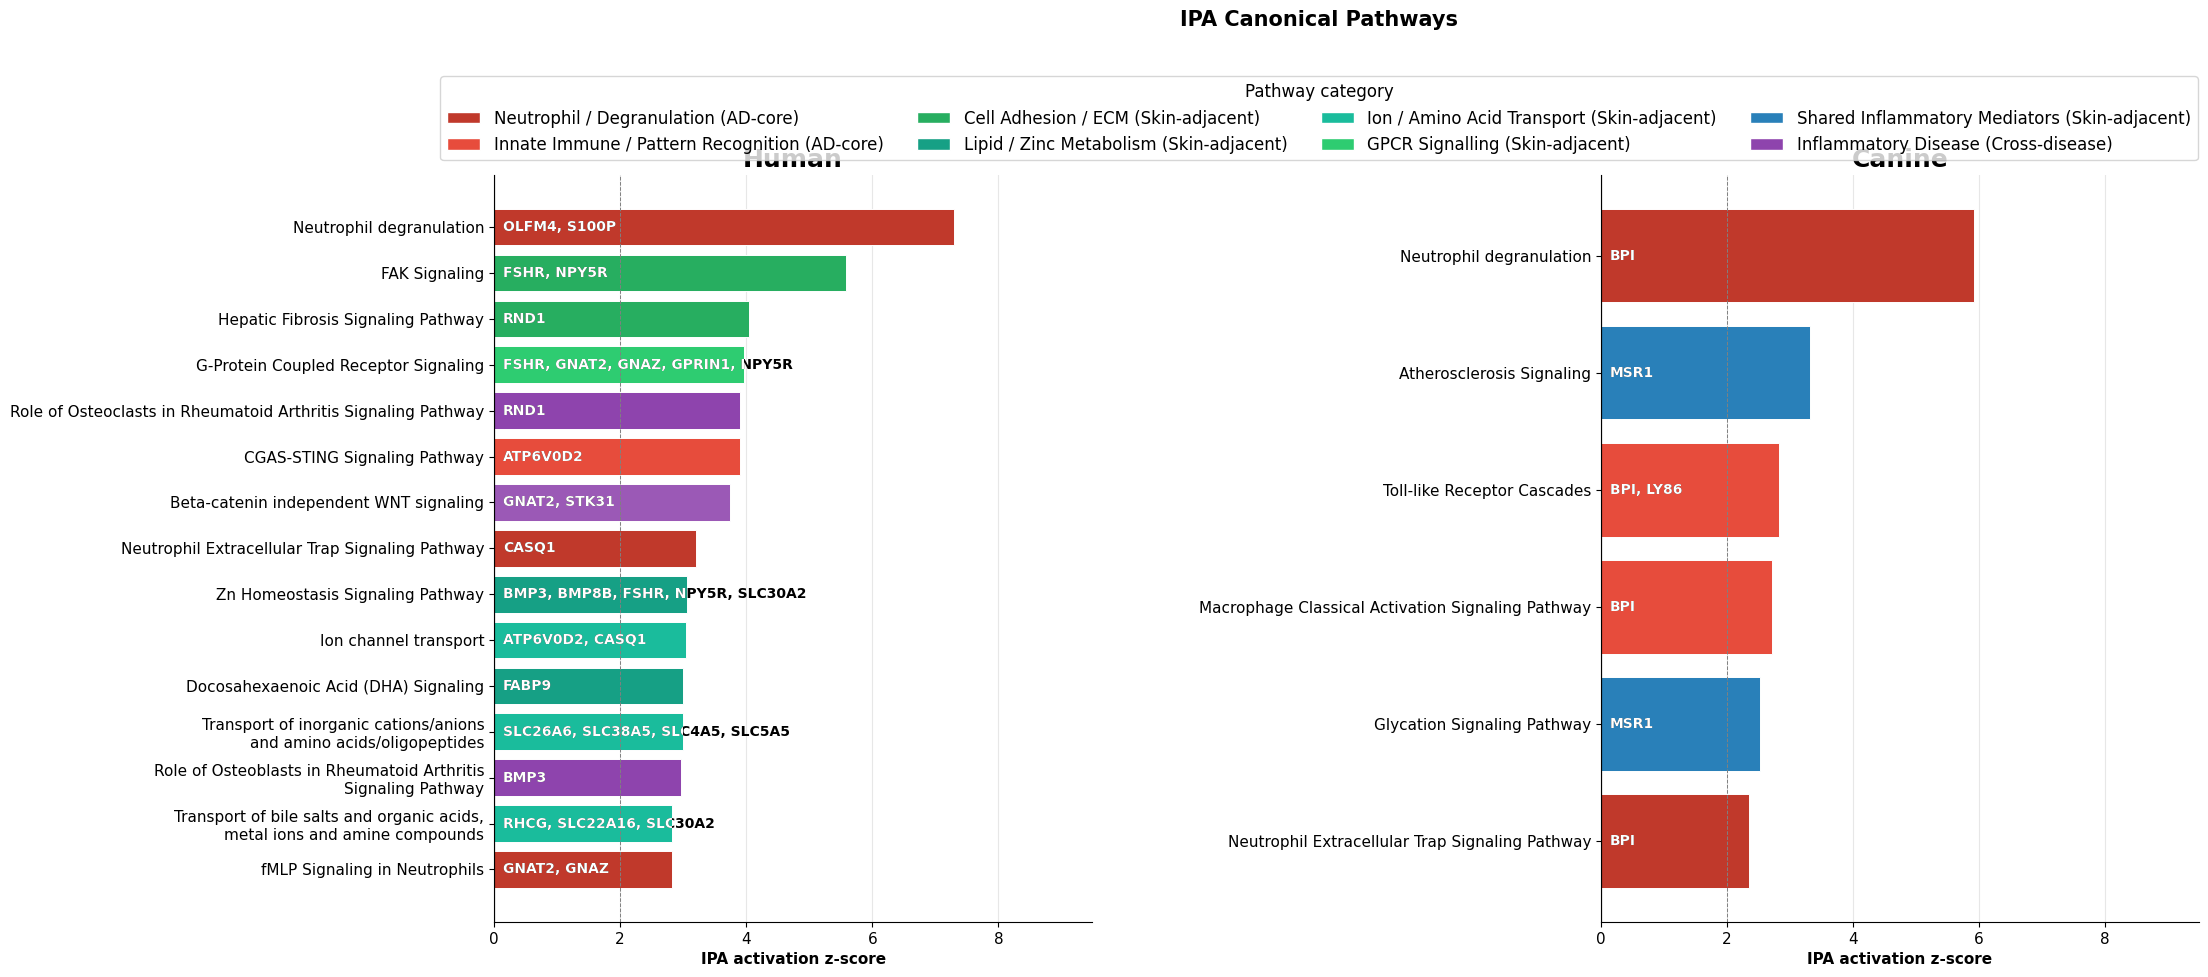

Saved → /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-CP_ZScore_BarChart.pdf
Saved → /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-CP_ZScore_BarChart.png
Saved → /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-CP_ZScore_BarChart.jpeg


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ── Helper: wrap only selected pathway names ─────────────────────────────────
def wrap_specific_pathway_names(df, name_col):
    df = df.copy()

    wrap_map = {
        "Transport of inorganic cations/anions and amino acids/oligopeptides":
            "Transport of inorganic cations/anions\nand amino acids/oligopeptides",

        "Transport of bile salts and organic acids, metal ions and amine compounds":
            "Transport of bile salts and organic acids,\nmetal ions and amine compounds",

        "Role of Osteoblasts in Rheumatoid Arthritis Signaling Pathway":
            "Role of Osteoblasts in Rheumatoid Arthritis\nSignaling Pathway"
    }

    df[name_col] = df[name_col].replace(wrap_map)
    return df


# ── Helper: draw one panel ───────────────────────────────────────────────────
def draw_bar_panel(ax, df, name_col, zscore_col, novel_col, cat_col,
                   species_label, max_z):

    df = df.copy()
    df[zscore_col] = pd.to_numeric(df[zscore_col], errors="coerce")
    df = df.dropna(subset=[zscore_col])
    df = df.sort_values(zscore_col, ascending=True)

    y_pos = np.arange(len(df))

    colors = [
        CAT_COLORS.get(cat, "#808080")
        for cat in df[cat_col]
    ]

    bars = ax.barh(
        y_pos,
        df[zscore_col],
        color=colors,
        edgecolor="white",
        linewidth=0.7
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df[name_col], fontsize=11)

    ax.set_xlim(0, max_z * 1.30)

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    ax.set_xlabel("IPA activation z-score", fontsize=11, fontweight="bold")
    ax.set_title(species_label, fontsize=18, fontweight="bold")

    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(2, color="gray", linestyle="--", linewidth=0.7)

    ax.grid(axis="x", linestyle="-", alpha=0.3)
    ax.set_axisbelow(True)

    for bar, y, z, genes in zip(bars, y_pos, df[zscore_col], df[novel_col]):

        genes = str(genes).strip()

        if genes and genes.lower() != "nan":

            label_x = max_z * 0.02
            fontsize_gene = 10

            ax.text(
                label_x,
                y,
                genes,
                ha="left",
                va="center",
                fontsize=fontsize_gene,
                fontweight="bold",
                color="black",
                clip_on=False,
                zorder=5
            )

            white_text = ax.text(
                label_x,
                y,
                genes,
                ha="left",
                va="center",
                fontsize=fontsize_gene,
                fontweight="bold",
                color="white",
                clip_on=True,
                zorder=6
            )

            white_text.set_clip_path(bar)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ── Helper: legend ───────────────────────────────────────────────────────────
def make_legend(fig, cat_order, ncol=4, fontsize=12):

    handles = [
        Patch(
            facecolor=CAT_COLORS[cat],
            edgecolor="white",
            label=cat
        )
        for cat in cat_order
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=ncol,
        fontsize=fontsize,
        frameon=True,
        title="Pathway category",
        title_fontsize=fontsize
    )


# ── Draw Figure CP ───────────────────────────────────────────────────────────
ROW_H   = 0.50
FIG_TOP = 1.4
FIG_BOT = 0.8

# Filter Human rows containing novel genes
has_novel_hcp = (
    hcp_plot["Novel_Genes_in_Row"].notna() &
    (hcp_plot["Novel_Genes_in_Row"].astype(str).str.strip() != "") &
    (hcp_plot["Novel_Genes_in_Row"].astype(str).str.lower() != "nan")
)

hcp_plot_filtered = hcp_plot[has_novel_hcp].reset_index(drop=True)

# Filter Canine rows containing novel genes
has_novel_ccp = (
    ccp_plot["Novel_Genes_in_Row"].notna() &
    (ccp_plot["Novel_Genes_in_Row"].astype(str).str.strip() != "") &
    (ccp_plot["Novel_Genes_in_Row"].astype(str).str.lower() != "nan")
)

ccp_plot_filtered = ccp_plot[has_novel_ccp].reset_index(drop=True)

# Wrap selected long pathway names
hcp_plot_filtered = wrap_specific_pathway_names(
    hcp_plot_filtered,
    "Ingenuity Canonical Pathways"
)

ccp_plot_filtered = wrap_specific_pathway_names(
    ccp_plot_filtered,
    "Ingenuity Canonical Pathways"
)

# Calculate maximum z-score
max_z_cp = max(
    hcp_plot_filtered["z-score"].max(),
    ccp_plot_filtered["z-score"].max()
)

fig_h = (
    max(len(hcp_plot_filtered), len(ccp_plot_filtered))
    * ROW_H + FIG_TOP + FIG_BOT
)

fig_w = 22

fig, axes = plt.subplots(
    1, 2,
    figsize=(fig_w, fig_h),
    gridspec_kw={"wspace": 0.85}
)

fig.suptitle(
    "IPA Canonical Pathways",
    fontsize=15,
    fontweight="bold",
    y=1.05,
    x=0.5
)

draw_bar_panel(
    axes[0],
    hcp_plot_filtered,
    name_col="Ingenuity Canonical Pathways",
    zscore_col="z-score",
    novel_col="Novel_Genes_in_Row",
    cat_col="Pathway_Category",
    species_label="Human",
    max_z=max_z_cp
)

draw_bar_panel(
    axes[1],
    ccp_plot_filtered,
    name_col="Ingenuity Canonical Pathways",
    zscore_col="z-score",
    novel_col="Novel_Genes_in_Row",
    cat_col="Pathway_Category",
    species_label="Canine",
    max_z=max_z_cp
)

# Legend
all_cats_cp = (
    list(hcp_plot_filtered["Pathway_Category"].unique()) +
    list(ccp_plot_filtered["Pathway_Category"].unique())
)

cat_order_cp = [
    c for c in CAT_COLORS
    if c in all_cats_cp and "off-target" not in c.lower()
]

make_legend(
    fig,
    cat_order_cp,
    ncol=4,
    fontsize=12
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])

output_base_path_cp = Path(
    "/content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-CP_ZScore_BarChart"
)

fig.savefig(f"{output_base_path_cp}.pdf", bbox_inches="tight", dpi=300)
fig.savefig(f"{output_base_path_cp}.png", bbox_inches="tight", dpi=300)
fig.savefig(f"{output_base_path_cp}.jpeg", bbox_inches="tight", dpi=300)

plt.show()

print(f"Saved → {output_base_path_cp}.pdf")
print(f"Saved → {output_base_path_cp}.png")
print(f"Saved → {output_base_path_cp}.jpeg")

---
## Figure DB: Diseases & Biofunctions

In [14]:
# ── prepare DB data ──────────────────────────────────────────────────────────
# Selection strategy (per species, sorted by z-score):
#   Tier 1 – ALL skin-adjacent / AD-core entries with novel genes (always show)
#   Tier 2 – Top N_OFFTARGET off-target (Metabolic/Neurological) entries
#   Tier 3 – Top 'Other' entries to fill up to MAX_DB_ROWS total

MAX_DB_ROWS  = 30
N_OFFTARGET  = 5      # max off-target (Metabolic / Neurological) entries to show

OFFTARGET_CATS = {'Metabolic / Endocrine (Off-target)', 'Neurological (Off-target)'}
PRIORITY_CATS  = {c for c in CAT_COLORS
                  if 'AD-core' in c or 'Skin-adjacent' in c}

def prepare_db(df):
    has_novel = (
        df['Novel_Genes_in_Row'].notna() &
        (df['Novel_Genes_in_Row'].astype(str).str.strip() != '') &
        (df['Novel_Genes_in_Row'].astype(str) != 'nan')
    )
    nv = df[has_novel].copy()

    tier1 = (nv[nv['Pathway_Category'].isin(PRIORITY_CATS)]
             .sort_values('Activation z-score', ascending=False))
    tier2 = (nv[nv['Pathway_Category'].isin(OFFTARGET_CATS)]
             .sort_values('Activation z-score', ascending=False)
             .head(N_OFFTARGET))
    tier3 = (nv[nv['Pathway_Category'] == 'Other']
             .sort_values('Activation z-score', ascending=False))

    # fill remaining quota from tier3
    used      = len(tier1) + len(tier2)
    remaining = max(MAX_DB_ROWS - used, 0)
    top_other = tier3.head(remaining)

    out = pd.concat([tier1, tier2, top_other], ignore_index=True)
    out = out.sort_values('Activation z-score', ascending=False).reset_index(drop=True)
    return out

hdb_plot = prepare_db(hdb)
cdb_plot = prepare_db(cdb)

print(f'Human DB rows for plot : {len(hdb_plot)}')
print(f'Canine DB rows for plot: {len(cdb_plot)}')
print('\nHuman DB categories:')
print(hdb_plot['Pathway_Category'].value_counts())
print('\nCanine DB categories:')
print(cdb_plot['Pathway_Category'].value_counts())

Human DB rows for plot : 30
Canine DB rows for plot: 30

Human DB categories:
Pathway_Category
Other                                         13
Lipid / Zinc Metabolism (Skin-adjacent)        6
Ion / Amino Acid Transport (Skin-adjacent)     4
Neurological (Off-target)                      3
Oxidative Stress (Skin-adjacent)               2
Metabolic / Endocrine (Off-target)             2
Name: count, dtype: int64

Canine DB categories:
Pathway_Category
Other                                         24
Oxidative Stress (Skin-adjacent)               3
Ion / Amino Acid Transport (Skin-adjacent)     2
Lipid / Zinc Metabolism (Skin-adjacent)        1
Name: count, dtype: int64


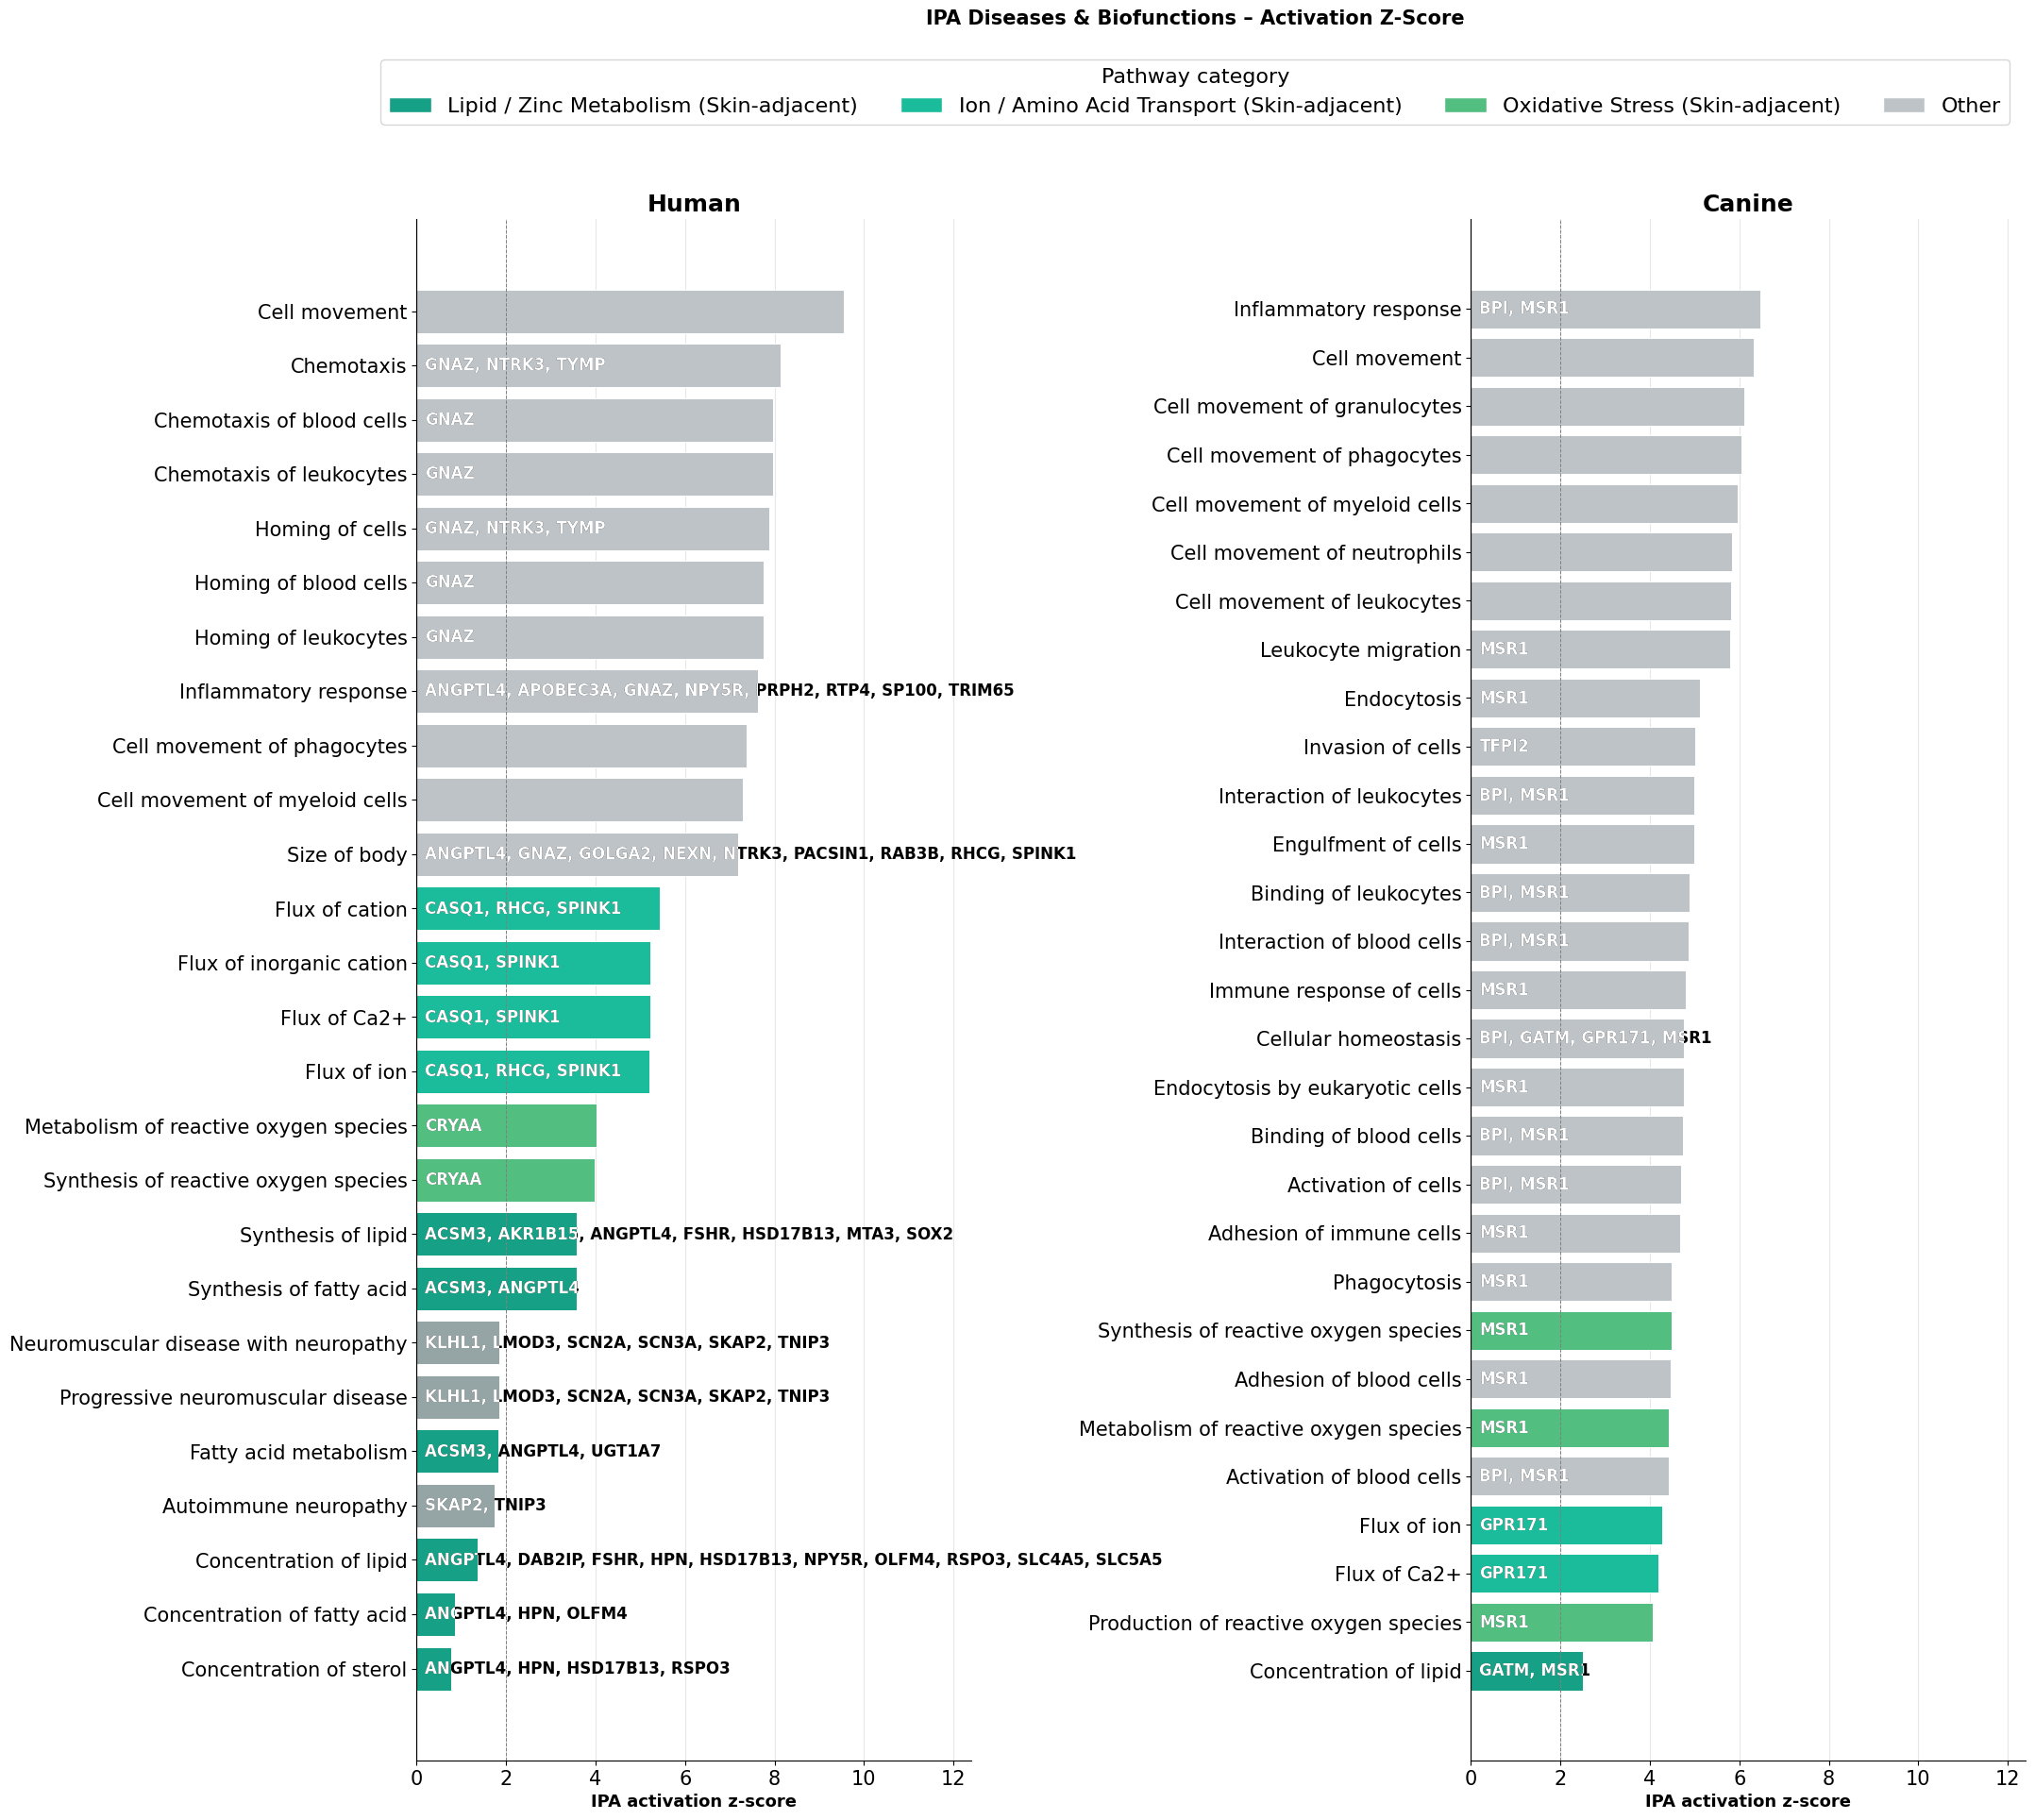

Saved → /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-DB_ZScore_BarChart.pdf
Saved → /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-DB_ZScore_BarChart.png
Saved → /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-DB_ZScore_BarChart.jpeg


In [57]:
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ── Helper: draw one panel ───────────────────
def draw_bar_panel(ax, df, name_col, zscore_col, novel_col, cat_col,
                   species_label, max_z, gene_label_fontsize=12,
                   xtick_labelsize=15, ytick_labelsize=15):

    df = df.copy()
    df[zscore_col] = pd.to_numeric(df[zscore_col], errors="coerce")
    df = df.dropna(subset=[zscore_col])
    df = df.sort_values(zscore_col, ascending=True)

    y_pos = np.arange(len(df))

    colors = [CAT_COLORS.get(cat, "#808080") for cat in df[cat_col]]

    bars = ax.barh(
        y_pos,
        df[zscore_col],
        color=colors,
        edgecolor="white",
        linewidth=0.7
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df[name_col], fontsize=ytick_labelsize)

    ax.set_xlim(0, max_z * 1.30)

    ax.tick_params(axis="x", labelsize=xtick_labelsize)
    ax.tick_params(axis="y", labelsize=ytick_labelsize)

    ax.set_xlabel("IPA activation z-score", fontsize=13, fontweight="bold")
    ax.set_title(species_label, fontsize=18, fontweight="bold", pad=6)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(2, color="gray", linestyle="--", linewidth=0.7)

    ax.grid(axis="x", linestyle="-", alpha=0.3)
    ax.set_axisbelow(True)

    for bar, y, z, genes in zip(bars, y_pos, df[zscore_col], df[novel_col]):

        genes = str(genes).strip()

        if genes and genes.lower() != "nan":

            label_x = max_z * 0.02

            ax.text(
                label_x,
                y,
                genes,
                ha="left",
                va="center",
                fontsize=gene_label_fontsize,
                fontweight="bold",
                color="black",
                clip_on=False,
                zorder=5
            )

            white_text = ax.text(
                label_x,
                y,
                genes,
                ha="left",
                va="center",
                fontsize=gene_label_fontsize,
                fontweight="bold",
                color="white",
                clip_on=True,
                zorder=6
            )

            white_text.set_clip_path(bar)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ── Helper: legend ────────────────────────
def make_legend_local(fig, cat_order, ncol=4, fontsize=16): # Increased fontsize again

    handles = [
        Patch(
            facecolor=CAT_COLORS[cat],
            edgecolor="white",
            label=cat
        )
        for cat in cat_order
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        borderaxespad=0,
        ncol=ncol,
        fontsize=fontsize,
        frameon=True,
        title="Pathway category",
        title_fontsize=fontsize # Increased title_fontsize again
    )


# ── Draw Figure DB ──────────────────────────

has_novel_hdb = (
    hdb_plot["Novel_Genes_in_Row"].notna() &
    (hdb_plot["Novel_Genes_in_Row"].astype(str).str.strip() != "") &
    (hdb_plot["Novel_Genes_in_Row"].astype(str).str.lower() != "nan")
)

hdb_plot_filtered = hdb_plot[has_novel_hdb].reset_index(drop=True)

has_novel_cdb = (
    cdb_plot["Novel_Genes_in_Row"].notna() &
    (cdb_plot["Novel_Genes_in_Row"].astype(str).str.strip() != "") &
    (cdb_plot["Novel_Genes_in_Row"].astype(str).str.lower() != "nan")
)

cdb_plot_filtered = cdb_plot[has_novel_cdb].reset_index(drop=True)

remove_terms = [
    "Pancreatic cancer",
    "Pancreatic carcinoma",
    "Migration of cells",
    "Cell movement of tumor cell lines"
]

remove_pattern = "|".join(remove_terms)

hdb_plot_filtered = hdb_plot_filtered[
    ~hdb_plot_filtered["Diseases or Functions Annotation"]
    .astype(str)
    .str.contains(remove_pattern, case=False, na=False)
].reset_index(drop=True)

cdb_plot_filtered = cdb_plot_filtered[
    ~cdb_plot_filtered["Diseases or Functions Annotation"]
    .astype(str)
    .str.contains(remove_pattern, case=False, na=False)
].reset_index(drop=True)


def clear_cell_movement_genes(df):
    df = df.copy()

    mask = (
        df["Diseases or Functions Annotation"]
        .astype(str)
        .str.contains("Cell movement", case=False, na=False)
    )

    df.loc[mask, "Novel_Genes_in_Row"] = ""

    return df


hdb_plot_filtered = clear_cell_movement_genes(hdb_plot_filtered)
cdb_plot_filtered = clear_cell_movement_genes(cdb_plot_filtered)

max_z_db = max(
    hdb_plot_filtered["Activation z-score"].max(),
    cdb_plot_filtered["Activation z-score"].max()
)

# Reduced top/bottom margins for publication-style compactness
ROW_H_DB = 0.70
FIG_TOP_DB = 0.45
FIG_BOT_DB = 0.45
fig_w = 22

fig_h_db = (
    max(len(hdb_plot_filtered), len(cdb_plot_filtered))
    * ROW_H_DB + FIG_TOP_DB + FIG_BOT_DB
)

fig2, axes2 = plt.subplots(
    1, 2,
    figsize=(fig_w, fig_h_db),
    gridspec_kw={"wspace": 0.90}
)

fig2.suptitle(
    "IPA Diseases & Biofunctions – Activation Z-Score",
    fontsize=15,
    fontweight="bold",
    y=0.985,
    x=0.5
)

draw_bar_panel(
    axes2[0],
    hdb_plot_filtered,
    name_col="Diseases or Functions Annotation",
    zscore_col="Activation z-score",
    novel_col="Novel_Genes_in_Row",
    cat_col="Pathway_Category",
    species_label="Human",
    max_z=max_z_db,
    gene_label_fontsize=12,
    xtick_labelsize=15,
    ytick_labelsize=15
)

draw_bar_panel(
    axes2[1],
    cdb_plot_filtered,
    name_col="Diseases or Functions Annotation",
    zscore_col="Activation z-score",
    novel_col="Novel_Genes_in_Row",
    cat_col="Pathway_Category",
    species_label="Canine",
    max_z=max_z_db,
    gene_label_fontsize=12,
    xtick_labelsize=15,
    ytick_labelsize=15
)

all_cats_db = (
    list(hdb_plot_filtered["Pathway_Category"].unique()) +
    list(cdb_plot_filtered["Pathway_Category"].unique())
)

cat_order_db = [
    c for c in CAT_COLORS
    if c in all_cats_db and "off-target" not in c.lower()
]

make_legend_local(
    fig2,
    cat_order_db,
    ncol=4,
    fontsize=16 # Changed fontsize for the legend
)

plt.tight_layout(rect=[0, 0.025, 1, 0.92])

output_base_path_db = Path(
    "/content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures/IPA-DB_ZScore_BarChart"
)

fig2.savefig(f"{output_base_path_db}.pdf", bbox_inches="tight", dpi=300)
fig2.savefig(f"{output_base_path_db}.png", bbox_inches="tight", dpi=300)
fig2.savefig(f"{output_base_path_db}.jpeg", bbox_inches="tight", dpi=300)

plt.show()

print(f"Saved → {output_base_path_db}.pdf")
print(f"Saved → {output_base_path_db}.png")
print(f"Saved → {output_base_path_db}.jpeg")

In [16]:
# ── summary ──────────────────────────────────────────────────────────────────
print('=== FIGURE SUMMARY ===')
print()
print('IPA-CP  →', out_cp.name)
print(f'  Human : {len(hcp_plot)} pathways')
print(f'  Canine: {len(ccp_plot)} categorised pathways (Other excluded)')
print()
print('IPA-DB  →', out_db.name)
print(f'  Human : {len(hdb_plot)} Diseases/Functions entries '
      f'(top {MAX_DB_ROWS} with novel genes)')
print(f'  Canine: {len(cdb_plot)} entries')
print()
print('Both figures saved as PDF + PNG under', FIG_DIR)

=== FIGURE SUMMARY ===

IPA-CP  → IPA-CP_ZScore_BarChart.pdf
  Human : 47 pathways
  Canine: 35 categorised pathways (Other excluded)

IPA-DB  → IPA-DB_ZScore_BarChart.pdf
  Human : 30 Diseases/Functions entries (top 30 with novel genes)
  Canine: 30 entries

Both figures saved as PDF + PNG under Results/NB02/Figures
